# Machine Learning Lab — Week 02

## Lab Activities

**Name:** Haider Ali  
**Roll Number:** 23-NTU-CS-FL-1254


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Find the provided dataset folder.
DATA_DIR = Path(".")


# Activity 1 — Medical Insurance Cost Prediction

## Objective

Predict a person's medical insurance cost from the supplied **Medical Cost Personal Dataset**.

### Required steps

- Load and explore the dataset.
- Use `age`, `bmi`, `children`, `smoker`, and `region` as input features.
- Use `charges` as the target.
- Encode categorical features.
- Scale numerical features.
- Train a Linear Regression model.
- Evaluate using RMSE and R² score.
- Plot predicted costs against actual costs.

In [3]:
# Load the dataset
insurance = pd.read_csv(DATA_DIR / "Medical Cost Personal Datasets.csv")

print("Shape:", insurance.shape)
print("\nFirst 5 rows:")
print(insurance.head().to_string(index=False))

print("\nMissing values:")
print(insurance.isnull().sum().to_string())

Shape: (1338, 7)

First 5 rows:
 age    sex    bmi  children smoker    region     charges
  19 female 27.900         0    yes southwest 16884.92400
  18   male 33.770         1     no southeast  1725.55230
  28   male 33.000         3     no southeast  4449.46200
  33   male 22.705         0     no northwest 21984.47061
  32   male 28.880         0     no northwest  3866.85520

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0


In [4]:
# Features and target exactly as specified in the activity
X = insurance[["age", "bmi", "children", "smoker", "region"]]
y = insurance["charges"]

numeric_features = ["age", "bmi", "children"]
categorical_features = ["smoker", "region"]

# Scale numeric features and one-hot encode categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

RMSE: 5796.77
R² Score: 0.7836


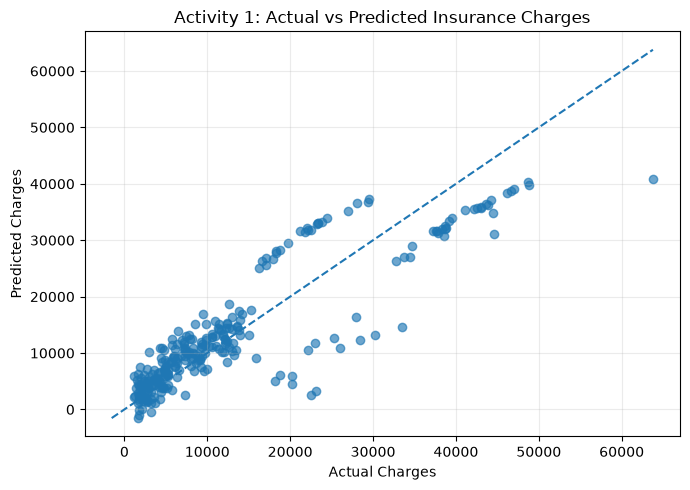

In [5]:
# Plot Predicted vs Actual Costs
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.65)

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())
plt.plot([minimum, maximum], [minimum, maximum], linestyle="--")

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Activity 1: Actual vs Predicted Insurance Charges")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Activity 2 — Telco Customer Churn Prediction

## Objective

Predict whether a customer will churn using the supplied **Telco Customer Churn** dataset.

### Required steps

- Load the dataset.
- Use `tenure`, `MonthlyCharges`, `Contract`, and `InternetService`.
- Encode categorical variables.
- Train a Logistic Regression model.
- Evaluate Accuracy, Precision, Recall, and F1-score.
- Plot a Confusion Matrix.
- Plot an ROC Curve.

In [6]:
# Load the dataset
churn = pd.read_csv(DATA_DIR / "Telco Customer Churn.csv")

print("Shape:", churn.shape)
print("\nSelected columns:")
print(
    churn[
        ["tenure", "MonthlyCharges", "Contract", "InternetService", "Churn"]
    ].head().to_string(index=False)
)

print("\nMissing values in selected columns:")
print(
    churn[
        ["tenure", "MonthlyCharges", "Contract", "InternetService", "Churn"]
    ].isnull().sum().to_string()
)

Shape: (7043, 21)

Selected columns:
 tenure  MonthlyCharges       Contract InternetService Churn
      1           29.85 Month-to-month             DSL    No
     34           56.95       One year             DSL    No
      2           53.85 Month-to-month             DSL   Yes
     45           42.30       One year             DSL    No
      2           70.70 Month-to-month     Fiber optic   Yes

Missing values in selected columns:
tenure             0
MonthlyCharges     0
Contract           0
InternetService    0
Churn              0


In [7]:
# Select activity features and encode the target
X = churn[["tenure", "MonthlyCharges", "Contract", "InternetService"]]
y = churn["Churn"].map({"No": 0, "Yes": 1})

numeric_features = ["tenure", "MonthlyCharges"]
categorical_features = ["Contract", "InternetService"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.7750
Precision: 0.5941
Recall   : 0.4813
F1-score : 0.5318


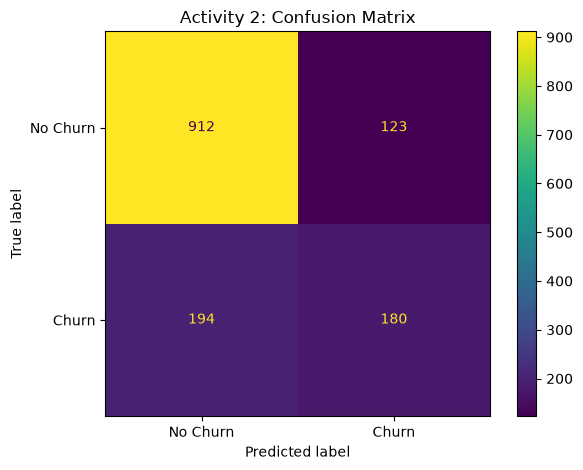

In [8]:
# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Churn", "Churn"]
)

plt.title("Activity 2: Confusion Matrix")
plt.tight_layout()
plt.show()

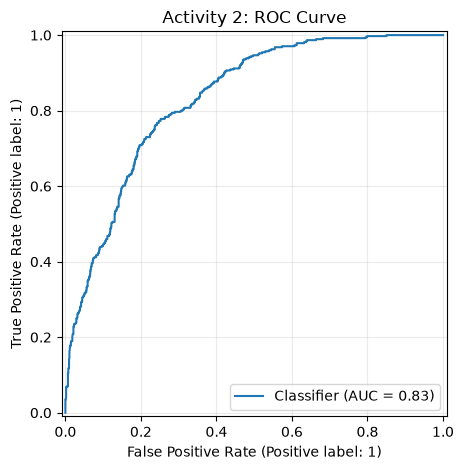

In [9]:
# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob)

plt.title("Activity 2: ROC Curve")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Activity 3 — Car Price Prediction

## Objective

Compare Linear Regression with Polynomial Regression of degrees 2, 3, and 4 for used-car price prediction.

### Dataset note

The activity slide suggests fields such as `Kms_Driven`, `Year`, `Engine`, and `Horsepower`.  
However, the supplied `Car Price Prediction.csv` does **not** contain `Kms_Driven`, `Year`, or `Engine`.

To solve the activity using the provided file without inventing missing columns, this notebook uses the available numeric predictors:

- `horsepower`
- `enginesize`
- `citympg`
- `highwaympg`

The target is `price`.

For the fitted-curve visualization, horsepower is varied while the other predictors are held at their median values.

In [10]:
# Load the supplied car-price dataset
cars = pd.read_csv(DATA_DIR / "Car Price Prediction.csv")

print("Shape:", cars.shape)
print("\nAvailable columns:")
print(cars.columns.tolist())

features = ["horsepower", "enginesize", "citympg", "highwaympg"]
target = "price"

print("\nSelected data:")
print(cars[features + [target]].head().to_string(index=False))

print("\nMissing values:")
print(cars[features + [target]].isnull().sum().to_string())

Shape: (205, 26)

Available columns:
['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']

Selected data:
 horsepower  enginesize  citympg  highwaympg   price
        111         130       21          27 13495.0
        111         130       21          27 16500.0
        154         152       19          26 16500.0
        102         109       24          30 13950.0
        115         136       18          22 17450.0

Missing values:
horsepower    0
enginesize    0
citympg       0
highwaympg    0
price         0


In [11]:
# Prepare train/test data
X = cars[features]
y = cars[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

results = []

# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

results.append({
    "Model": "Linear Regression",
    "RMSE": np.sqrt(mean_squared_error(y_test, linear_pred)),
    "R2": r2_score(y_test, linear_pred)
})

# Polynomial Regression degrees 2, 3, and 4
poly_models = {}

for degree in [2, 3, 4]:
    model = Pipeline(
        steps=[
            ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
            ("scale", StandardScaler()),
            ("regressor", LinearRegression())
        ]
    )

    model.fit(X_train, y_train)
    prediction = model.predict(X_test)

    poly_models[degree] = model

    results.append({
        "Model": f"Polynomial Degree {degree}",
        "RMSE": np.sqrt(mean_squared_error(y_test, prediction)),
        "R2": r2_score(y_test, prediction)
    })

results_df = pd.DataFrame(results)

print("Model Performance:")
print(results_df.round(4).to_string(index=False))

Model Performance:
              Model       RMSE      R2
  Linear Regression  4058.5103  0.7914
Polynomial Degree 2  3904.8255  0.8069
Polynomial Degree 3  3873.9923  0.8099
Polynomial Degree 4 17025.9721 -2.6720


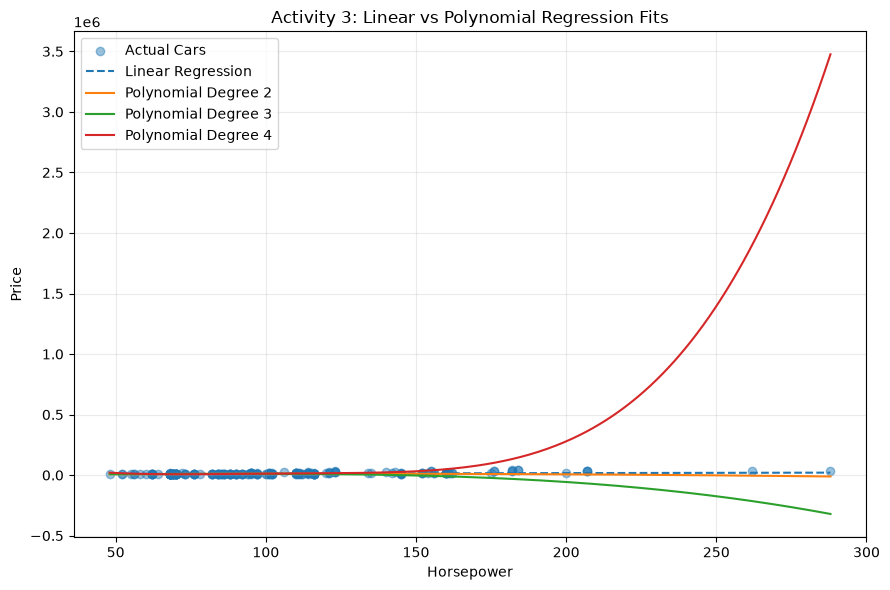

In [12]:
# Plot fitted curves for polynomial degrees 2, 3, and 4.
# Horsepower varies; the other predictors are fixed at their median values.

horsepower_range = np.linspace(
    cars["horsepower"].min(),
    cars["horsepower"].max(),
    250
)

median_engine = cars["enginesize"].median()
median_city = cars["citympg"].median()
median_highway = cars["highwaympg"].median()

curve_data = pd.DataFrame({
    "horsepower": horsepower_range,
    "enginesize": median_engine,
    "citympg": median_city,
    "highwaympg": median_highway
})

plt.figure(figsize=(9, 6))
plt.scatter(cars["horsepower"], cars["price"], alpha=0.45, label="Actual Cars")

# Linear reference fit
linear_curve = linear_model.predict(curve_data)
plt.plot(
    horsepower_range,
    linear_curve,
    linestyle="--",
    label="Linear Regression"
)

for degree in [2, 3, 4]:
    curve_prediction = poly_models[degree].predict(curve_data)
    plt.plot(
        horsepower_range,
        curve_prediction,
        label=f"Polynomial Degree {degree}"
    )

plt.xlabel("Horsepower")
plt.ylabel("Price")
plt.title("Activity 3: Linear vs Polynomial Regression Fits")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [13]:
# Identify the model with the lowest RMSE and the model with the highest R²

best_rmse_row = results_df.loc[results_df["RMSE"].idxmin()]
best_r2_row = results_df.loc[results_df["R2"].idxmax()]

print(
    f"Lowest RMSE: {best_rmse_row['Model']} "
    f"({best_rmse_row['RMSE']:.2f})"
)

print(
    f"Highest R²: {best_r2_row['Model']} "
    f"({best_r2_row['R2']:.4f})"
)

Lowest RMSE: Polynomial Degree 3 (3873.99)
Highest R²: Polynomial Degree 3 (0.8099)
